In [2]:
#Titanic_with_Deeplearning

In [4]:
# We will solve titnic project with using deep learnin

In [6]:
#We are going to predict who is going to survive, based on the Titanic dataset
#Since it is a yes no quesiton we will use classification
#read,examine,select usefull columns,EDA and fill empty columns
#convert objects that can be converted to float or integer
#decide on x and y, train the model

In [8]:
#pip install miceforest

In [114]:
import pandas as pd
pd.set_option("display.max_columns",55)

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import miceforest as mf 
import tensorflow as tf
from sklearn.preprocessing import normalize, scale
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [11]:
df=pd.read_csv("ttrain.csv")

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df2=pd.read_csv("ttest.csv")

In [14]:
df=pd.concat([df,df2])

In [15]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [16]:
df3 = df[['Age', 'Fare']]

In [17]:
df3.reset_index(drop=True, inplace=True)

In [18]:
df3

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
1304,NaN,8.0500
1305,39.0,108.9000
1306,38.5,7.2500
1307,NaN,8.0500


In [19]:
imp=mf.ImputationKernel(df3)

In [20]:
imp.complete_data()

,Age,Fare
0,22.00,7.2500
1,38.00,71.2833
2,26.00,7.9250
3,35.00,53.1000
4,35.00,8.0500
...,...,...
1304,30.00,8.0500
1305,39.00,108.9000
1306,38.50,7.2500
1307,14.00,8.0500


In [21]:
df['Age'] = imp.complete_data()["Age"]#NaN is filled with miceforest
df['Fare'] = imp.complete_data()['Fare']

In [22]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          2
dtype: int64

In [23]:
print(df.index.duplicated().sum())

418


In [24]:
df = df.reset_index(drop=True)

<Axes: xlabel='Embarked', ylabel='count'>

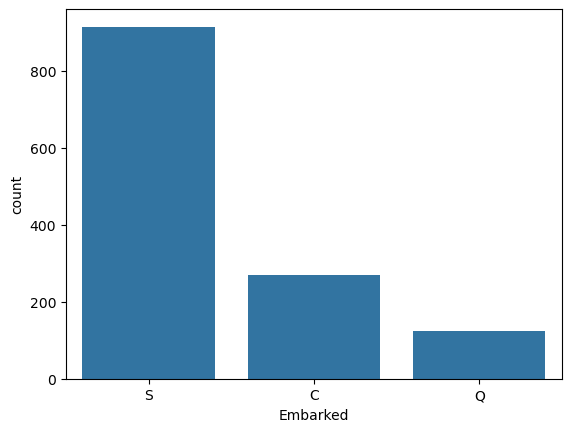

In [25]:
sns.countplot(x=df["Embarked"])

In [26]:
df['Embarked']=df['Embarked'].fillna(df["Embarked"].mode()[0])

In [27]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64

In [28]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

In [29]:
df=pd.get_dummies(df,drop_first=True)

In [50]:
train=df[:891]
test=df[891:]

In [52]:
x=train.drop(['Survived'],axis=1)
y=train[['Survived']]

In [54]:
x.info()#Since the number is less than 1000 results wouldn't be perfect

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_male    891 non-null    bool   
 6   Embarked_Q  891 non-null    bool   
 7   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(3)
memory usage: 37.5 KB


In [56]:
x=scale(x)

In [58]:
model=Sequential()
model.add(Dense(8,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [60]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)#You can stop training early when model validation loss (val_loss) stops recovery.

In [62]:
history=model.fit(x, y, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4459 - loss: 0.7170 - val_accuracy: 0.5196 - val_loss: 0.6871
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5865 - loss: 0.6788 - val_accuracy: 0.8380 - val_loss: 0.6519
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7646 - loss: 0.6531 - val_accuracy: 0.8268 - val_loss: 0.6052
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7684 - loss: 0.6087 - val_accuracy: 0.8156 - val_loss: 0.5431
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7505 - loss: 0.5637 - val_accuracy: 0.8212 - val_loss: 0.4875
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7860 - loss: 0.5174 - val_accuracy: 0.8268 - val_loss: 0.4403
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7940 - loss: 0.4902 - val_accuracy: 0.8380 - val_loss: 0.4151
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.4691 - val_accuracy: 0.8380 - 

In [64]:
loss, accuracy = model.evaluate(x, y, verbose=1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8398 - loss: 0.4038 


In [66]:
loss

0.3906032145023346

In [68]:
accuracy

0.8383838534355164

In [70]:
test=test.drop(['Survived'],axis=1)

In [74]:
test=scale(test)

In [76]:
pred=model.predict(test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [78]:
pred

array([[0.04062881],
       [0.63181716],
       [0.13205814],
       [0.18546586],
       [0.47236544],
       [0.10372453],
       [0.6299772 ],
       [0.68917245],
       [0.76376057],
       [0.05869931],
       [0.18982668],
       [0.19140103],
       [0.93436605],
       [0.08130954],
       [0.93294406],
       [0.8916887 ],
       [0.07227767],
       [0.13556974],
       [0.4498167 ],
       [0.7834459 ],
       [0.37072483],
       [0.10100732],
       [0.96500987],
       [0.48477507],
       [0.9695192 ],
       [0.05126563],
       [0.97416836],
       [0.17102061],
       [0.4830225 ],
       [0.01428204],
       [0.07430977],
       [0.18159766],
       [0.35593268],
       [0.10520566],
       [0.31640017],
       [0.06900138],
       [0.65952003],
       [0.59343314],
       [0.11618344],
       [0.12971613],
       [0.08726592],
       [0.47137508],
       [0.11035641],
       [0.8907767 ],
       [0.93358576],
       [0.09329044],
       [0.44317123],
       [0.034

In [80]:
y_pred_classes = (pred > 0.5).astype("int32")

In [82]:
y_pred_classes

array([[0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
    

In [94]:
sol=pd.DataFrame()
sol["PassengerId"]=df2["PassengerId"]
sol['Survived']=y_pred_classes

In [96]:
sol

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [100]:
sol["Survived"]=sol["Survived"].astype("int32")

In [104]:
sol.to_csv("Titanic_dl_sol.csv", index=False)

In [112]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │              14 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,409 (5.51 KB)

 Trainable params: 469 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 940 (3.68 KB)

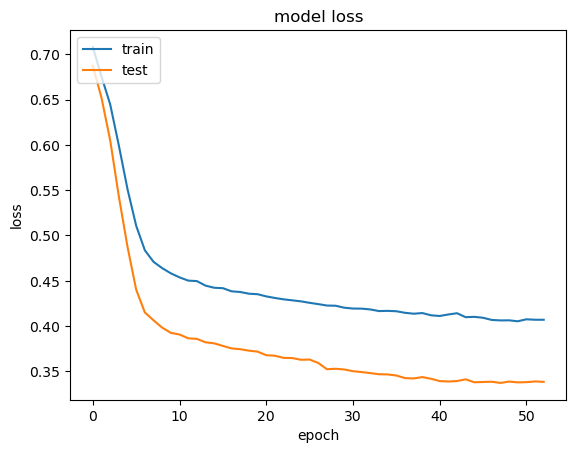

In [116]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

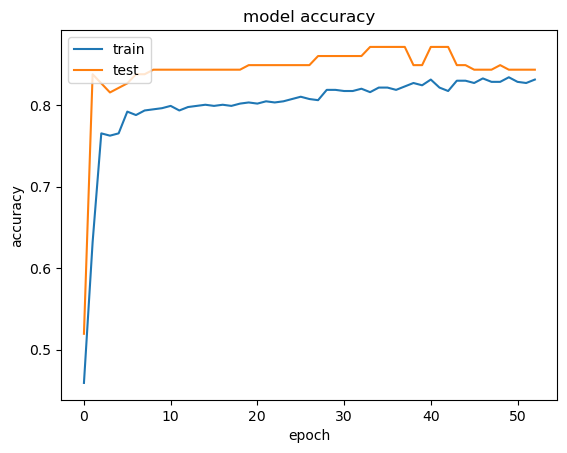

In [118]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
#

In [120]:
#Model Performance:
#The validation accuracy of your model is quite good (around 90%).
#Although the training accuracy is slightly lower, this is a good sign for generalization. 
#This indicates that the model is not overfitting the training data.
#No Overfitting or Underfitting:
#There is not a huge difference between training accuracy and validation accuracy, 
#indicating that the model performs well on both the training and validation set.
